Part A: Setting up the directory, packages, and environment for the datasets



In [ ]:
import os

#  Set this to the folder containing your CSV files
DATA_DIR = r'C:\Users\alipa\Documents\3- Academic\6- Data Science, phyton\1- class files\9- Time Series Modeling\Time-Series\Data'

In [ ]:
# Import the packages

! pip install pandas numpy matplotlib datetime statsmodels scipy


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import zscore

Part B: Downloading the datasets

In [ ]:
df_holidays = pd.read_csv(os.path.join(DATA_DIR, 'holidays.csv'))
display(df_holidays.head())

,date,locale,locale_name,description
0,2012-03-02,Local,Manta,Fundacion de Manta
1,2012-04-01,Regional,Cotopaxi,Provincializacion de Cotopaxi
2,2012-04-12,Local,Cuenca,Fundacion de Cuenca
3,2012-04-14,Local,Libertad,Cantonizacion de Libertad
4,2012-04-21,Local,Riobamba,Cantonizacion de Riobamba


In [ ]:
df_stores = pd.read_csv(os.path.join(DATA_DIR, 'stores.csv'))
display(df_stores.head())

,store_nbr,city,region
0,1,Quito,Pichincha
1,2,Quito,Pichincha
2,3,Quito,Pichincha
3,4,Quito,Pichincha
4,5,Santo Domingo,Santo Domingo de los Tsachilas


In [ ]:
df_oil = pd.read_csv(os.path.join(DATA_DIR, 'oil.csv'))
display(df_oil.head())

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [ ]:
df_timeseries = pd.read_csv(os.path.join(DATA_DIR, 'timeseries.csv'))
display(df_timeseries.head())

,date,unit_sales
0,2013-01-02,582.0
1,2013-01-03,310.0
2,2013-01-04,338.0
3,2013-01-05,654.0
4,2013-01-06,979.0


### Part C: Exploratory Data Analysis (EDA)

### EDA (df_holidays)

In [ ]:
#  Basic info: shape, dtypes, missing values
print("Shape:", df_holidays.shape)
print()
print("Column types:")
print(df_holidays.dtypes)
print()
print("Missing values:")
print(df_holidays.isnull().sum())
print()
print("Unique values per column:")
for col in df_holidays.columns:
    print(f"  {col}: {df_holidays[col].nunique()} unique values")

Shape: (350, 4)

Column types:
date           object
locale         object
locale_name    object
description    object
dtype: object

Missing values:
date           0
locale         0
locale_name    0
description    0
dtype: int64

Unique values per column:
  date: 312 unique values
  locale: 3 unique values
  locale_name: 24 unique values
  description: 103 unique values


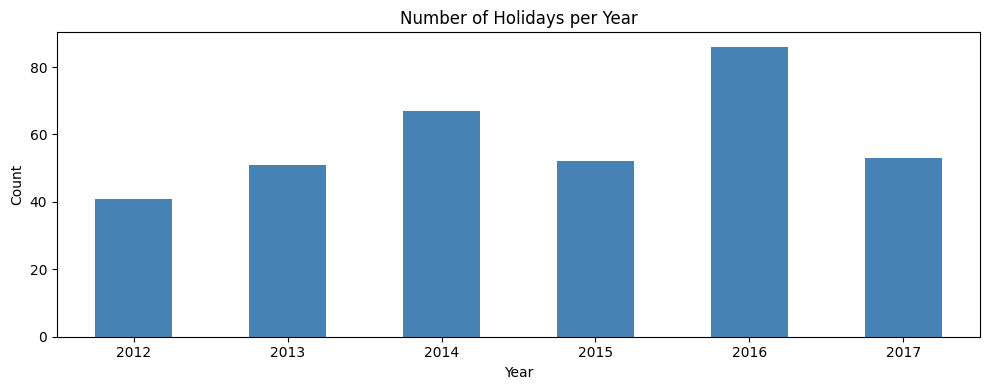

In [ ]:
# Holidays per year
df_holidays['date'] = pd.to_datetime(df_holidays['date'])
df_holidays['year'] = df_holidays['date'].dt.year

plt.figure(figsize=(10, 4))
df_holidays['year'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Number of Holidays per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

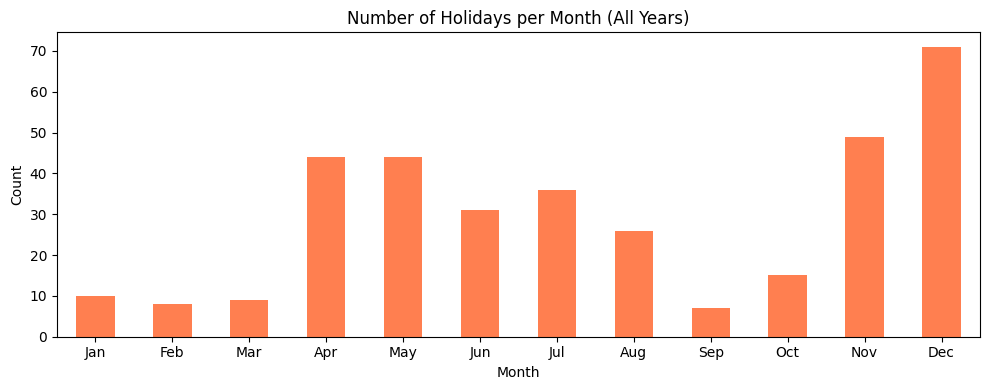

In [ ]:
# Holidays per month (aggregated across all years)
df_holidays['month'] = df_holidays['date'].dt.month

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_counts = df_holidays['month'].value_counts().sort_index()

plt.figure(figsize=(10, 4))
monthly_counts.plot(kind='bar', color='coral')
plt.title('Number of Holidays per Month (All Years)')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(ticks=range(12), labels=month_labels, rotation=0)
plt.tight_layout()
plt.show()

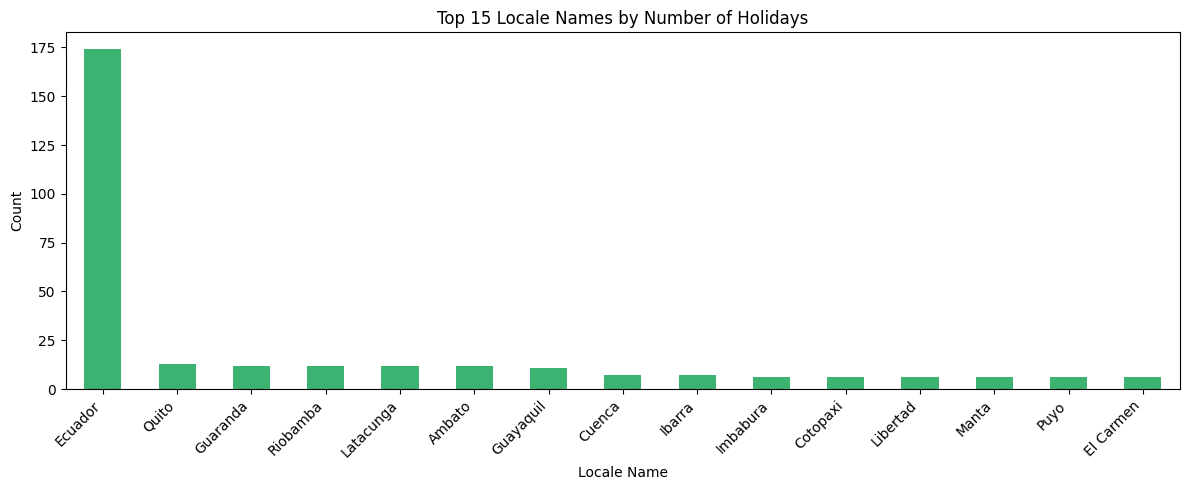

In [ ]:
#  Top 15 locale names with the most holidays
plt.figure(figsize=(12, 5))
df_holidays['locale_name'].value_counts().head(15).plot(kind='bar', color='mediumseagreen')
plt.title('Top 15 Locale Names by Number of Holidays')
plt.xlabel('Locale Name')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

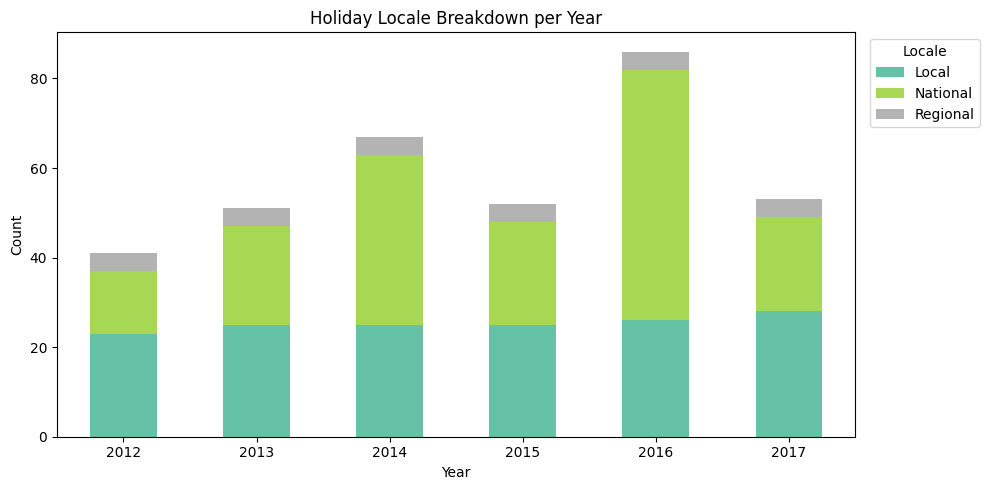

In [ ]:
#  Locale type breakdown per year (stacked bar)
locale_year = df_holidays.groupby(['year', 'locale']).size().unstack(fill_value=0)

locale_year.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='Set2')
plt.title('Holiday Locale Breakdown per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Locale', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

df_holidays head:


,date,locale,locale_name,description,year,month
0,2012-03-02,Local,Manta,Fundacion de Manta,2012,3
1,2012-04-01,Regional,Cotopaxi,Provincializacion de Cotopaxi,2012,4
2,2012-04-12,Local,Cuenca,Fundacion de Cuenca,2012,4
3,2012-04-14,Local,Libertad,Cantonizacion de Libertad,2012,4
4,2012-04-21,Local,Riobamba,Cantonizacion de Riobamba,2012,4



Visualizing df_holidays data:


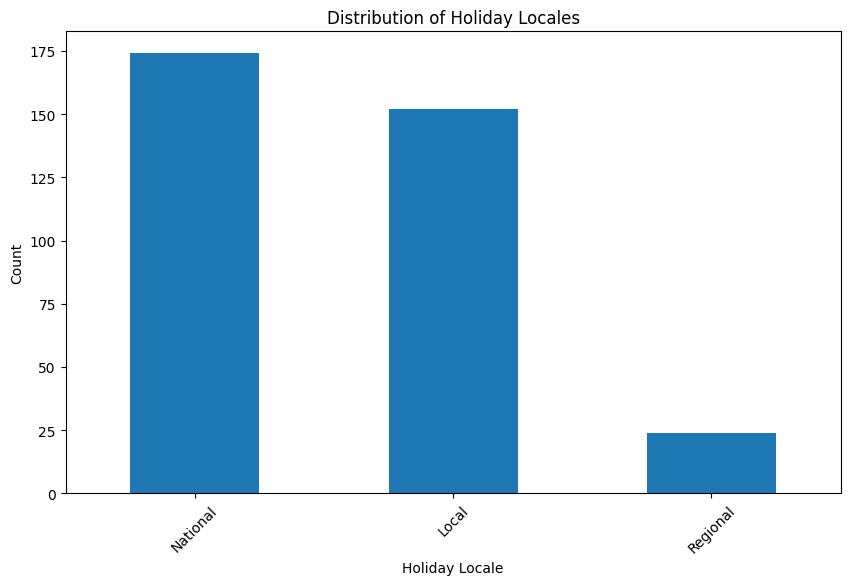

In [ ]:
print("df_holidays head:")
display(df_holidays.head())

print("\nVisualizing df_holidays data:")
# Bar plot for holiday types                                                                
plt.figure(figsize=(10, 6))
df_holidays['locale'].value_counts().plot(kind='bar')
plt.title('Distribution of Holiday Locales')
plt.xlabel('Holiday Locale')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

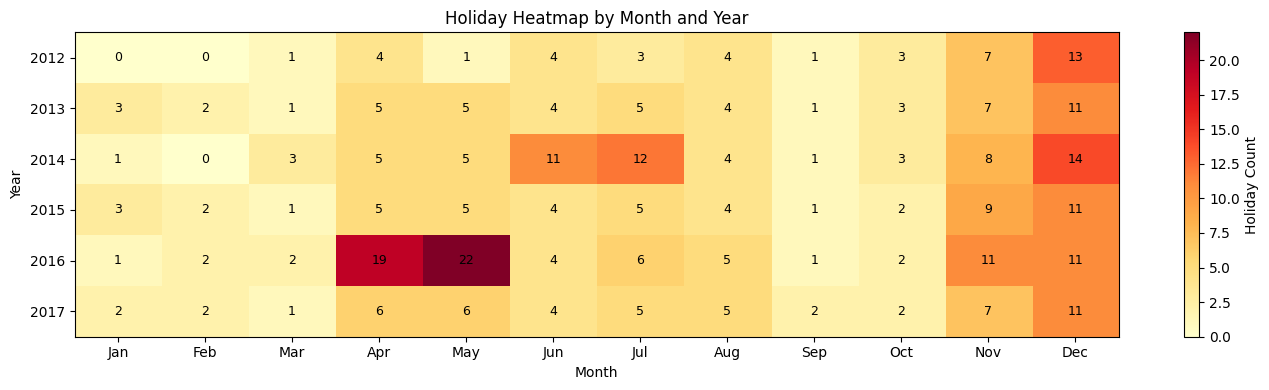

In [ ]:
# Heatmap: number of holidays by month and year
pivot = df_holidays.groupby(['year', 'month']).size().unstack(fill_value=0)
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(12))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
plt.colorbar(im, ax=ax, label='Holiday Count')
ax.set_title('Holiday Heatmap by Month and Year')
ax.set_xlabel('Month')
ax.set_ylabel('Year')

for i in range(len(pivot.index)):
    for j in range(12):
        ax.text(j, i, str(pivot.values[i, j]), ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### EDA (df_stores)

In [ ]:
# Basic info: shape, dtypes, missing values
print("Shape:", df_stores.shape)
print()
print("Column types:")
print(df_stores.dtypes)
print()
print("Missing values:")
print(df_stores.isnull().sum())
print()
print("Unique values per column:")
for col in df_stores.columns:
    print(f"  {col}: {df_stores[col].nunique()} unique values")

Shape: (54, 3)

Column types:
store_nbr     int64
city         object
region       object
dtype: object

Missing values:
store_nbr    0
city         0
region       0
dtype: int64

Unique values per column:
  store_nbr: 54 unique values
  city: 22 unique values
  region: 16 unique values


df_stores head:


,store_nbr,city,region
0,1,Quito,Pichincha
1,2,Quito,Pichincha
2,3,Quito,Pichincha
3,4,Quito,Pichincha
4,5,Santo Domingo,Santo Domingo de los Tsachilas


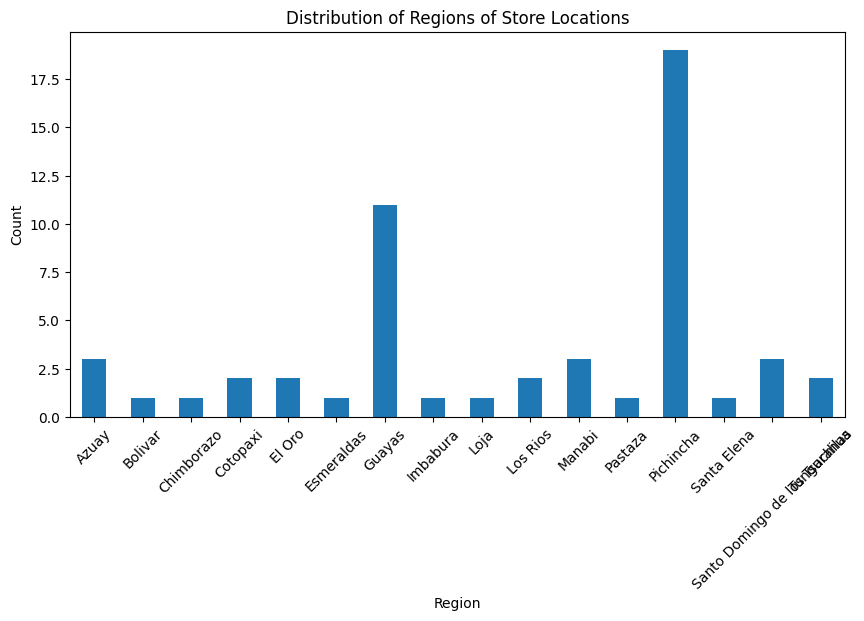

In [ ]:
print("df_stores head:")
display(df_stores.head())

# Bar plot for store clusters
plt.figure(figsize=(10, 5))
df_stores['region'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Regions of Store Locations')
plt.xlabel('Region')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

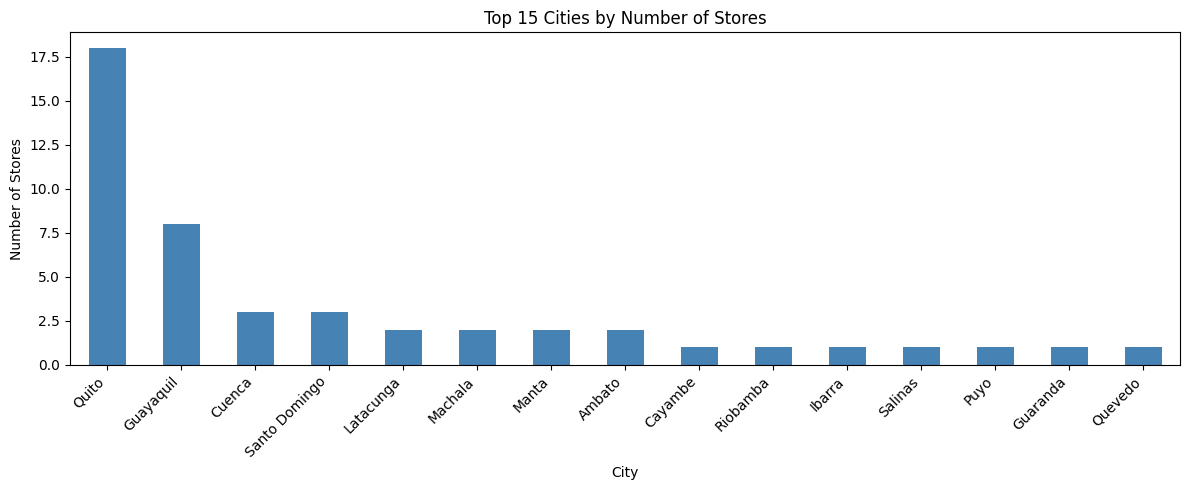

In [ ]:
# Top 15 cities by number of stores
# There are 22 cities in total, but we will show the top 15 for better visualization

plt.figure(figsize=(12, 5))
df_stores['city'].value_counts().head(15).plot(kind='bar', color='steelblue')
plt.title('Top 15 Cities by Number of Stores')
plt.xlabel('City')
plt.ylabel('Number of Stores')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### EDA (df_oil)

In [ ]:
# Basic info: shape, dtypes, missing values
df_oil['date'] = pd.to_datetime(df_oil['date'])
print("Shape:", df_oil.shape)
print()
print("Column types:")
print(df_oil.dtypes)
print()
print("Missing values:")
print(df_oil.isnull().sum())
print()
print("Date range:", df_oil['date'].min(), "to", df_oil['date'].max())
print("Total days spanned:", (df_oil['date'].max() - df_oil['date'].min()).days)

Shape: (1218, 2)

Column types:
date          datetime64[ns]
dcoilwtico           float64
dtype: object

Missing values:
date           0
dcoilwtico    43
dtype: int64

Date range: 2013-01-01 00:00:00 to 2017-08-31 00:00:00
Total days spanned: 1703


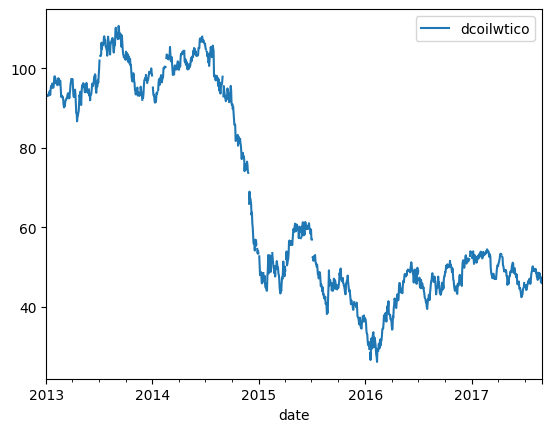

In [ ]:
# Oil dataset - Convert date format and plotted the line graph
df_oil['date'] = pd.to_datetime(df_oil['date'])
df_oil.plot(x='date', y='dcoilwtico')
plt.show()

In [ ]:
# Oil dataset
# Impute missing values in the 'dcoilwtico' column of df_oil using linear interpolation
df_oil['dcoilwtico'] = df_oil['dcoilwtico'].interpolate(method='linear')

# Display the head of the DataFrame to show the changes and check for remaining NaNs
print("DataFrame head after interpolation:")
display(df_oil.head())

# Check if there are any remaining NaNs in the 'dcoilwtico' column
print("Number of missing values in 'dcoilwtico' after interpolation:", df_oil['dcoilwtico'].isnull().sum())

DataFrame head after interpolation:


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


Number of missing values in 'dcoilwtico' after interpolation: 1


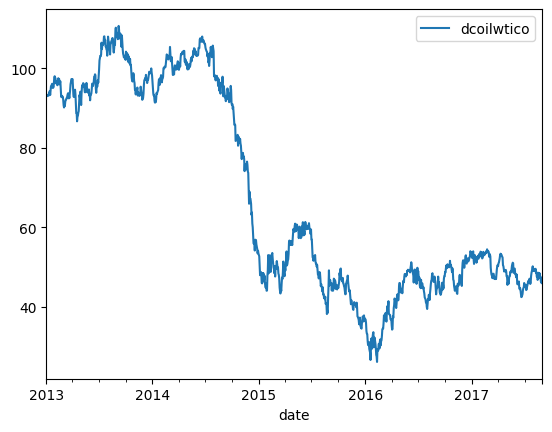

In [ ]:
# Oil dataset - Let's check it again to see if the values were filled
df_oil['date'] = pd.to_datetime(df_oil['date'])
df_oil.plot(x='date', y='dcoilwtico')
plt.show()

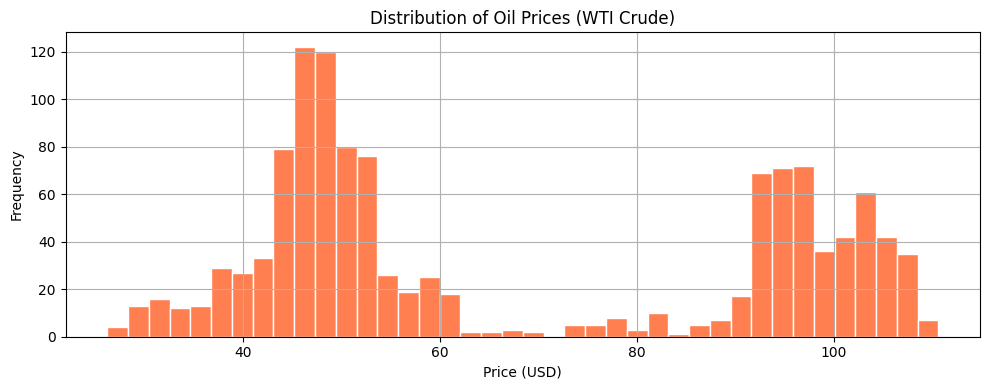

In [ ]:
# Distribution of oil prices (histogram)
plt.figure(figsize=(10, 4))
df_oil['dcoilwtico'].dropna().hist(bins=40, color='coral', edgecolor='white')
plt.title('Distribution of Oil Prices (WTI Crude)')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

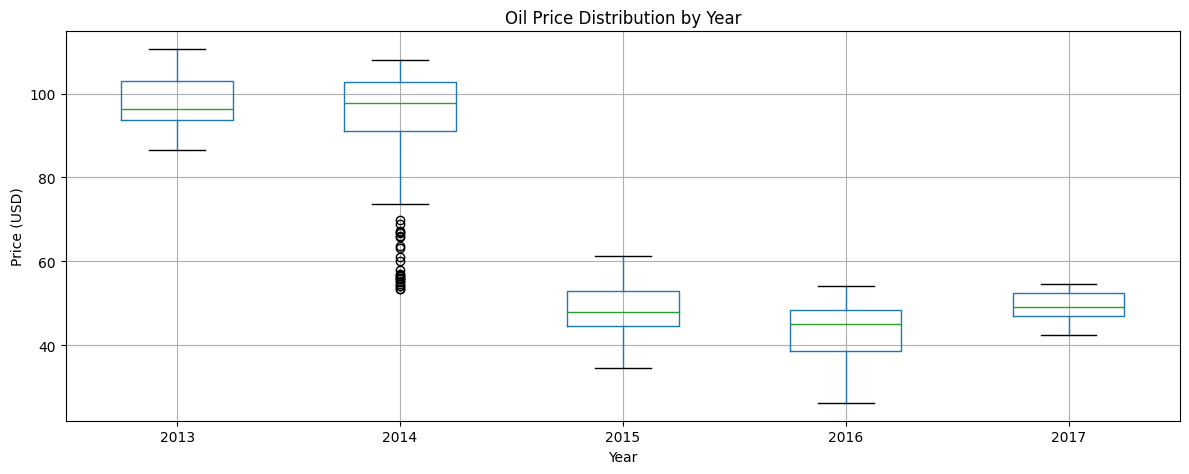

In [ ]:
# Oil price distribution by year (boxplot)
df_oil['year'] = df_oil['date'].dt.year

df_oil.boxplot(column='dcoilwtico', by='year', figsize=(12, 5))
plt.title('Oil Price Distribution by Year')
plt.suptitle('')
plt.xlabel('Year')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()

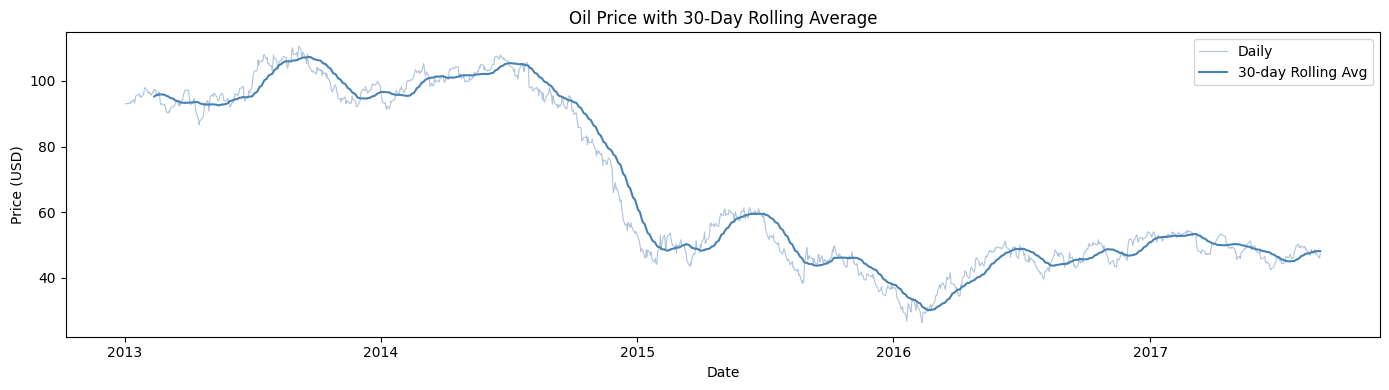

In [ ]:
# 30-day rolling average of oil prices
df_oil_sorted = df_oil.sort_values('date')
df_oil_sorted['rolling_30d'] = df_oil_sorted['dcoilwtico'].rolling(window=30).mean()

plt.figure(figsize=(14, 4))
plt.plot(df_oil_sorted['date'], df_oil_sorted['dcoilwtico'], color='lightsteelblue', linewidth=0.8, label='Daily')
plt.plot(df_oil_sorted['date'], df_oil_sorted['rolling_30d'], color='steelblue', linewidth=1.5, label='30-day Rolling Avg')
plt.title('Oil Price with 30-Day Rolling Average')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

### EDA (df_timeseries)

In [ ]:
# Basic info: shape, dtypes, missing values
df_timeseries['date'] = pd.to_datetime(df_timeseries['date'])
print("Shape:", df_timeseries.shape)
print()
print("Column types:")
print(df_timeseries.dtypes)
print()
print("Missing values:")
print(df_timeseries.isnull().sum())
print()
print("Date range:", df_timeseries['date'].min(), "to", df_timeseries['date'].max())
print("Total days spanned:", (df_timeseries['date'].max() - df_timeseries['date'].min()).days)
print()
print("Summary statistics:")
print(df_timeseries['unit_sales'].describe())

Shape: (452, 2)

Column types:
date          datetime64[ns]
unit_sales           float64
dtype: object

Missing values:
date          0
unit_sales    0
dtype: int64

Date range: 2013-01-02 00:00:00 to 2014-03-31 00:00:00
Total days spanned: 453

Summary statistics:
count     452.000000
mean      480.090708
std       170.839776
min         4.000000
25%       358.000000
50%       445.500000
75%       578.250000
max      1203.000000
Name: unit_sales, dtype: float64


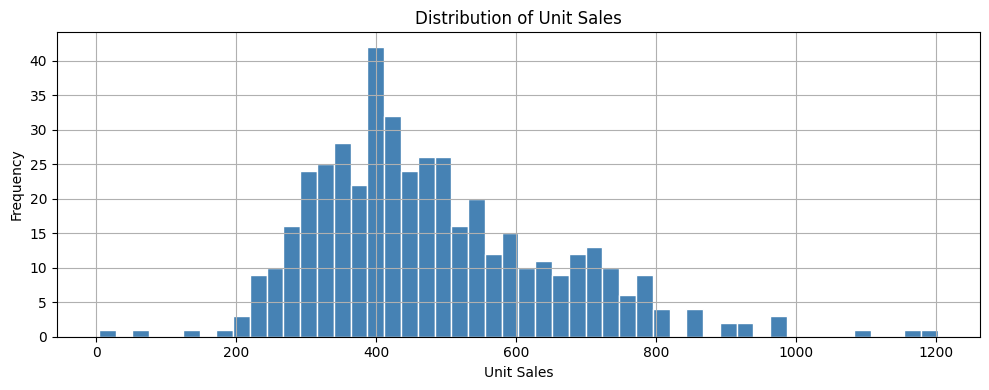

In [ ]:
# Distribution of unit sales
plt.figure(figsize=(10, 4))
df_timeseries['unit_sales'].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of Unit Sales')
plt.xlabel('Unit Sales')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

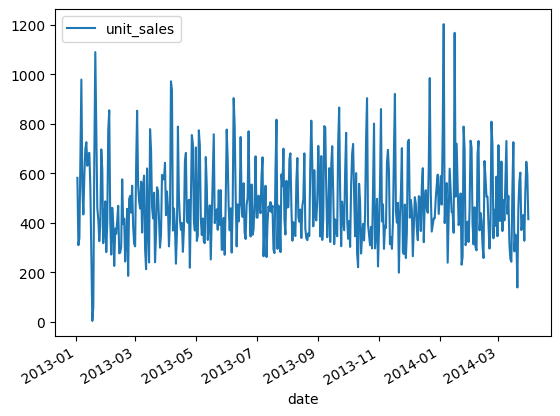

In [ ]:
# Time Series dataset - Convert date format and plotted the line graph
df_timeseries['date'] = pd.to_datetime(df_timeseries['date'])
df_timeseries.plot(x='date', y='unit_sales')
plt.show()

In [ ]:
# Time Series dataset - Use ADF test function to check if it is stationarity (H0 = non-stationary vs. H1 = stationary)
def run_adf(timeseries):
    """Performs Augmented Dickey-Fuller test on a given time series."""
    adf_result = adfuller(timeseries)
    p_value = adf_result[1]
    print(f'P-value is {p_value}')
    if p_value <= 0.05:
        print("The series is stationary (reject H0).")
    else:
        print("The series is non-stationary (fail to reject H0).")

In [ ]:
# Time Series dataset - Test stationarity on original series
run_adf(df_timeseries['unit_sales'])

P-value is 1.453017741687818e-05
The series is stationary (reject H0).


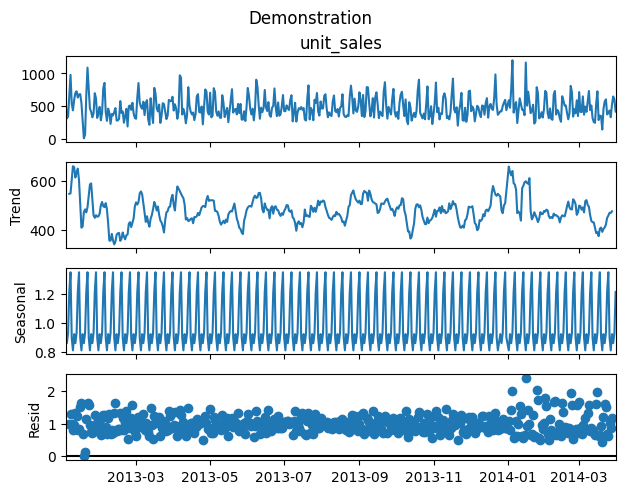

In [ ]:
# Time Series dataset - Decompose the time series into Trend × Seasonality × Residual (multiplicative model)
df_timeseries_indexed = df_timeseries.set_index('date')
decomp_mul = seasonal_decompose(df_timeseries_indexed['unit_sales'], model="multiplicative", period=7)
decomp_mul.plot()
plt.suptitle("Demonstration", y=1.02)
plt.show()

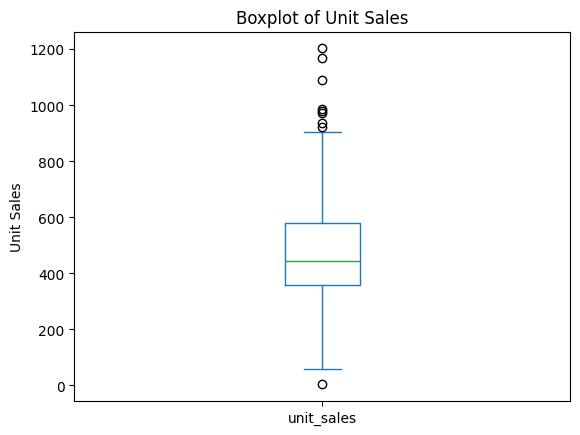

In [ ]:
# Time Series dataset - Detecting Outliers with a Boxplot
df_timeseries.plot.box(y='unit_sales', title='Boxplot of Unit Sales')
plt.ylabel('Unit Sales')
plt.show()

In [ ]:
# Time Series dataset -Calculate Z-scores for the 'unit_sales' column to provide a statistical measure for outliers
df_timeseries['unit_sales_zscore'] = zscore(df_timeseries['unit_sales'])

# Display the head of the DataFrame with the new Z-score column
print("DataFrame head with Z-scores:")
display(df_timeseries.head())

DataFrame head with Z-scores:


,date,unit_sales,unit_sales_zscore
0,2013-01-02,582.0,0.597181
1,2013-01-03,310.0,-0.996719
2,2013-01-04,338.0,-0.832641
3,2013-01-05,654.0,1.019095
4,2013-01-06,979.0,2.923570


<Figure size 1200x600 with 0 Axes>

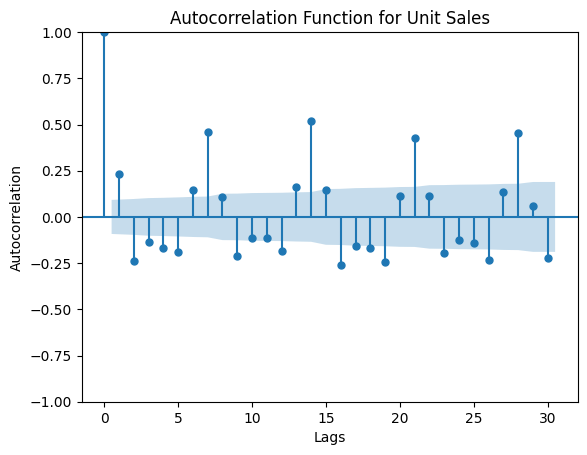

In [ ]:
# Time Series dataset - Create an autocorrelation plot for 'unit_sales'
plt.figure(figsize=(12, 6))
plot_acf(df_timeseries['unit_sales'], lags=30)
plt.title('Autocorrelation Function for Unit Sales')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.show()